In [3]:
import ddr_tools as ddr #custom module
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact #interactive plots
import os
from matplotlib import ticker
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import NullFormatter
import meshio

In [4]:
def load_square_mesh(filename):
    """
    Loads and parses a 2D mesh in msh format

    Parameters:
    - filename: path to the mesh file

    Returns:
    - Mesh object
    """
    # LOAD MESH:
    mesh_file_path = filename
    mesh = meshio.read(mesh_file_path)
    # face2node connectivity
    faces = mesh.cells[2].data # for structured cell2node is the 3rd field ""
    # node coordinates
    coords = mesh.points
    # Add dummy column to host faces with more than 3 vertices
    faces = np.c_[faces, -1*np.ones(faces.shape[0])]
    faces = faces.astype(int)
    # Sizes
    Nfaces_init = faces.shape[0]
    Npoints_init = coords.shape[0]
    Nfaces = Nfaces_init
    Npoints = Npoints_init
    # Mask for elements: 0 if uncut, 1 if cut, 2 if generated by cut
    cut_faces = np.zeros(Nfaces)
    # gamme_edge2face connectivity is created by function break_mesh
    # in/ex mask (0: in, 1: ex, -1: cut cell)
    side_mask = -1*np.ones(Nfaces)
    # boundary mask, code:
    # 0: internal
    # 1: x=-0.5
    # 2: y=-0.5
    # 3: x= 0.5
    # 4: y= 0.5
    bnd_mask = np.zeros(Npoints_init)
    return ddr.Mesh (faces, Nfaces, Nfaces_init, coords, Npoints, Npoints_init, cut_faces, side_mask, bnd_mask)


In [13]:
# data 
L = 0.5 # semi-side
sigma_min = 1
sigma_plus = 1
phi_datum = lambda x,y: 0 # have to define it as lambda function and as real
phi_gamma = 0
g_min  = -1
g_plus =  1
    
A_min  = sigma_plus/(sigma_plus+sigma_min)*(g_plus-g_min-phi_gamma)/L
A_plus = sigma_min/sigma_plus*A_min
B_min  = g_min+A_min*L
B_plus = g_plus-A_plus*L

# ref sol: expressions in x,y 
ref_sol_min = lambda x,y: A_min*(x+L)+g_min
ref_sol_plus = lambda x,y: A_plus*(x-L)+g_plus

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_min=ref_sol_min, ref_sol_plus=ref_sol_plus: \
          ddr.reference_1D_solution(mesh, dof, ref_sol_min, ref_sol_plus) 

eta = 1e10

In [14]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40, 80]
mesh_filenames = ["square_struc_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_struc_L1_N"+str(size)+".vtk" for size in size_list]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = load_square_mesh(mesh_filenames[i]) # adapted for structured mesh
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) # OK
    # break mesh
    ddr.break_mesh_1D(mesh) # OK
    # mark boundaries
    ddr.mark_bnd_points(mesh) # OK
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) # OK
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) # OK
    S = ddr.assemble_S(mesh) # OK
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    #A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    A =  G+S+eta*N_gamma+np.transpose(M_gamma) # TEST!!!!!!
    b = eta*b_phi
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A, b)
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

[2.41833797 0.56860295 1.13536947 1.40470144]


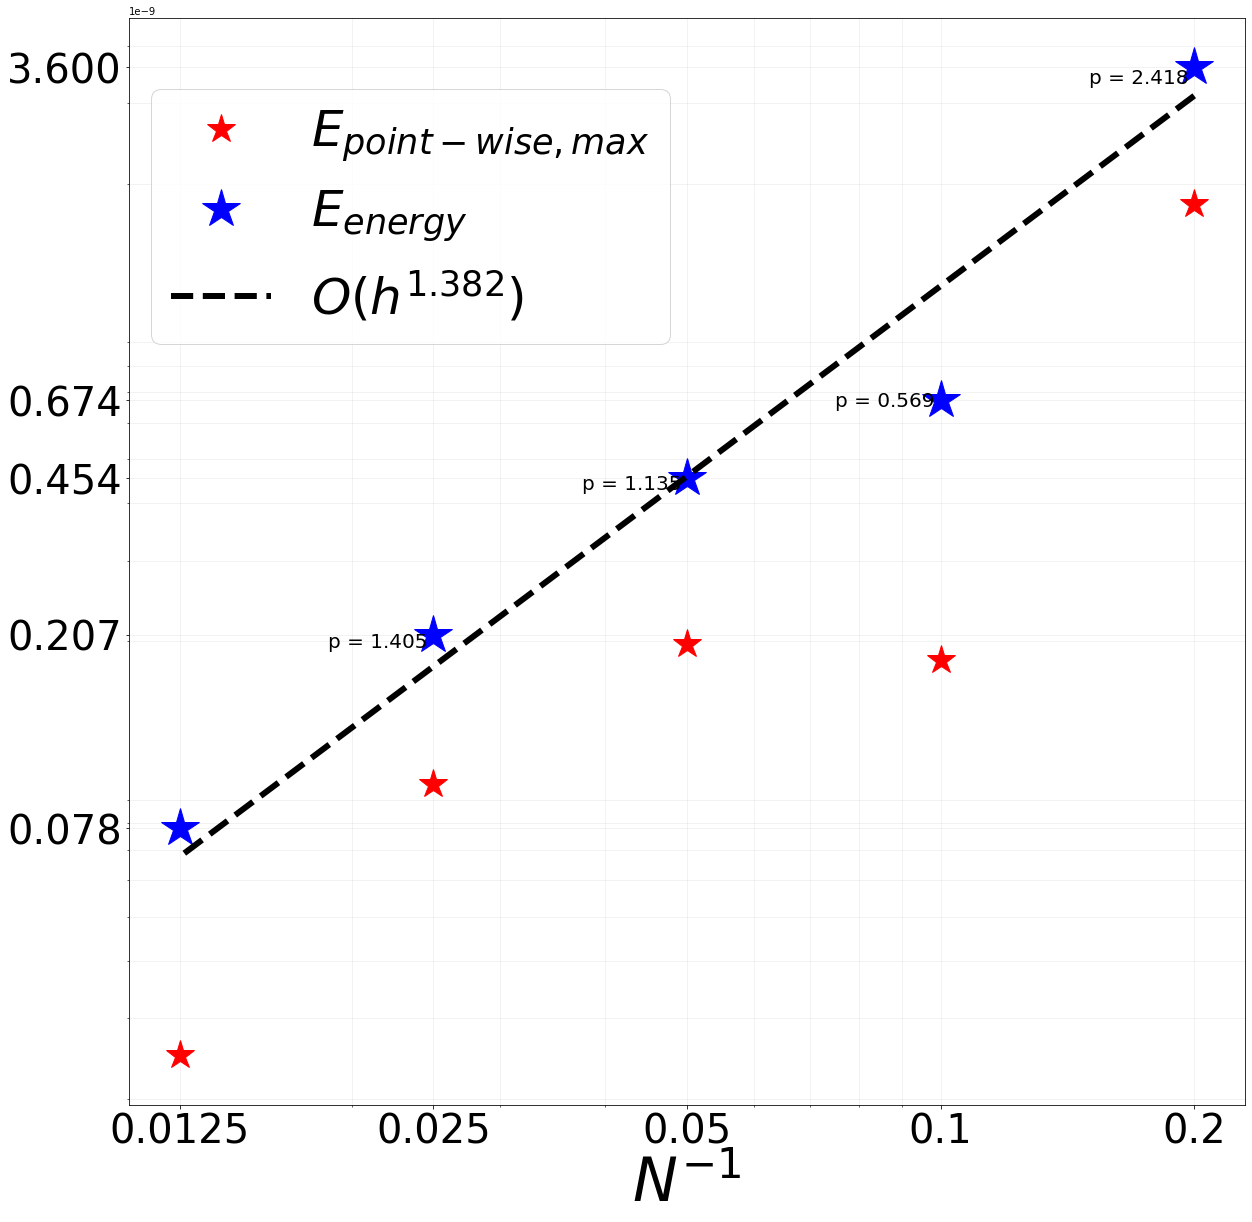

In [15]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = len(size_list)
fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))


ax.loglog(h,errors_L0, '*', label="$E_{point-wise,max}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
#ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )
#ax.loglog(h,h_sq/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-2})$", color="black", linewidth= line_width )
# estimate and plot order of convergence
orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]
ax.loglog(h,h_p/np.mean(h_p)*np.mean(errors_energy),'--', label="$O(h^{"+str(np.round(p,3))+"})$", color="black", linewidth= line_width )
# print 
for i in range(len(size_list)-1):
    text = "p = "+str(np.round(orders[i],3))
    pos_x = 0.5*(h[i+1]+h[i])
    pos_y = 0.5*(errors_energy[i+1]+errors_energy[i]) - 0.4*(errors_energy[i+1]-errors_energy[i])
    ax.text(pos_x, pos_y, text, fontsize=20, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

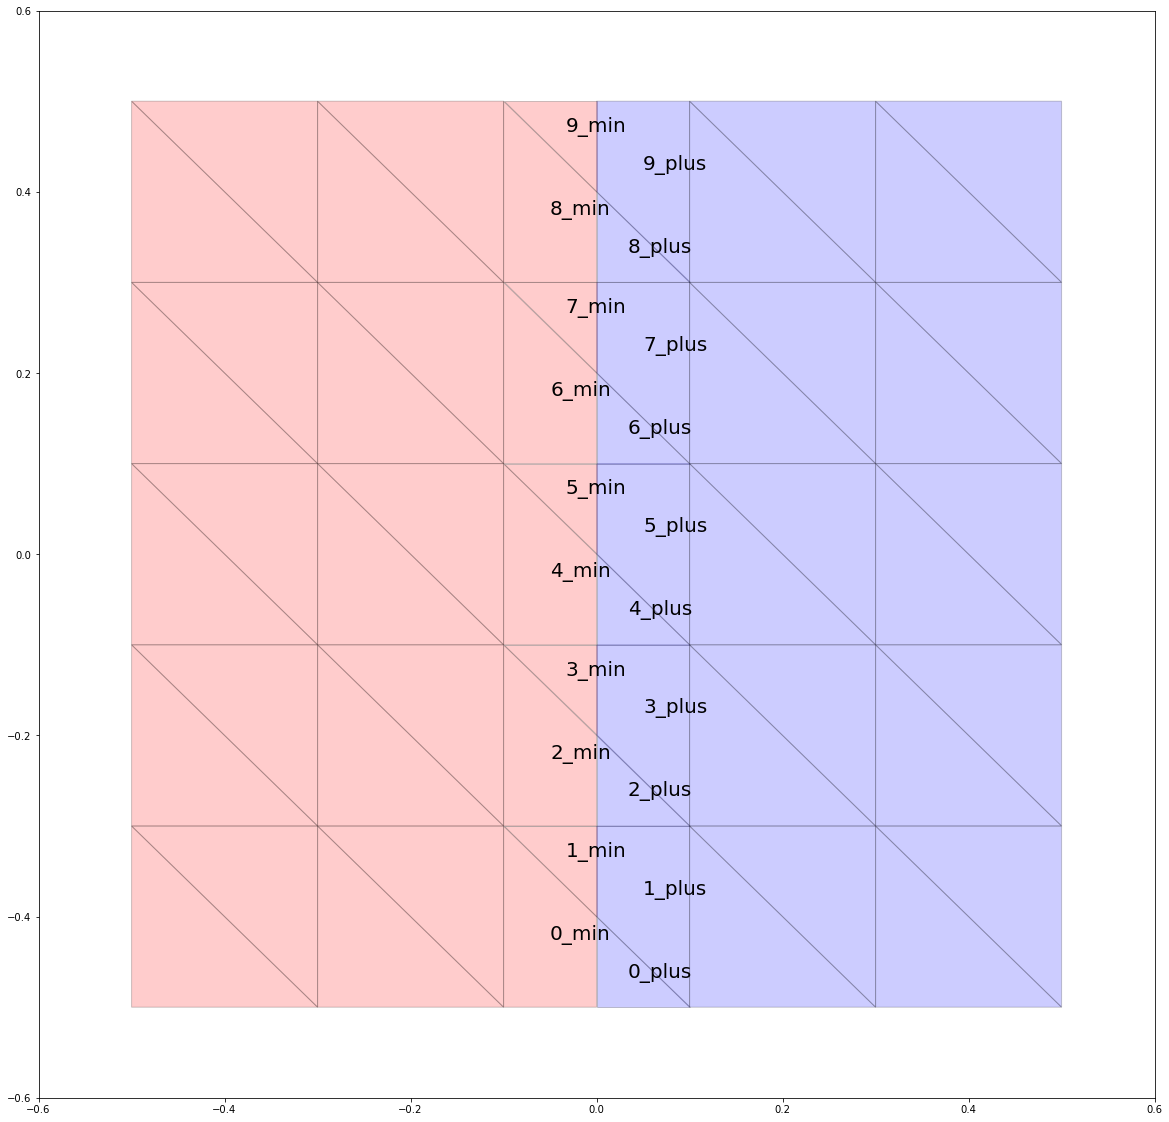

In [62]:
# CHECK MESH

def check_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            # determine number of vertices
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
            # determine side    
            if (mesh.side_mask[ifa]==0):
                color = 'red'
            elif (mesh.side_mask[ifa]==1):
                color = 'blue'
            else:
                color = 'green'
            for ino in range(nvert):
                p1 = mesh.coords[mesh.faces[ifa,ino],:]
                verts.append(p1[0:2])
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
    for (ie, couple) in enumerate(mesh.gamma_edges):
        ifa1 = couple[0]
        ifa2 = couple[1]
        text_pos_1 = ddr.barycenter(mesh, ifa1)
        text_pos_2 = ddr.barycenter(mesh, ifa2)
        text_content_1= str(ie)+"_min"
        text_content_2= str(ie)+"_plus"
        ax.text(text_pos_1[0], text_pos_1[1], text_content_1, fontsize=20, color='black')
        ax.text(text_pos_2[0], text_pos_2[1], text_content_2, fontsize=20, color='black')
        
n=0
mesh = Meshes[n]
check_mesh(mesh)

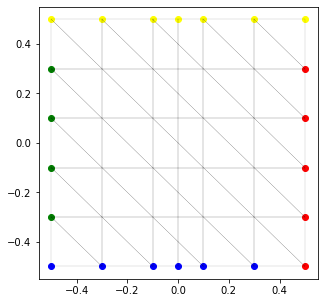

In [63]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    
visualize_bnd_points_with_dof(Meshes[n])

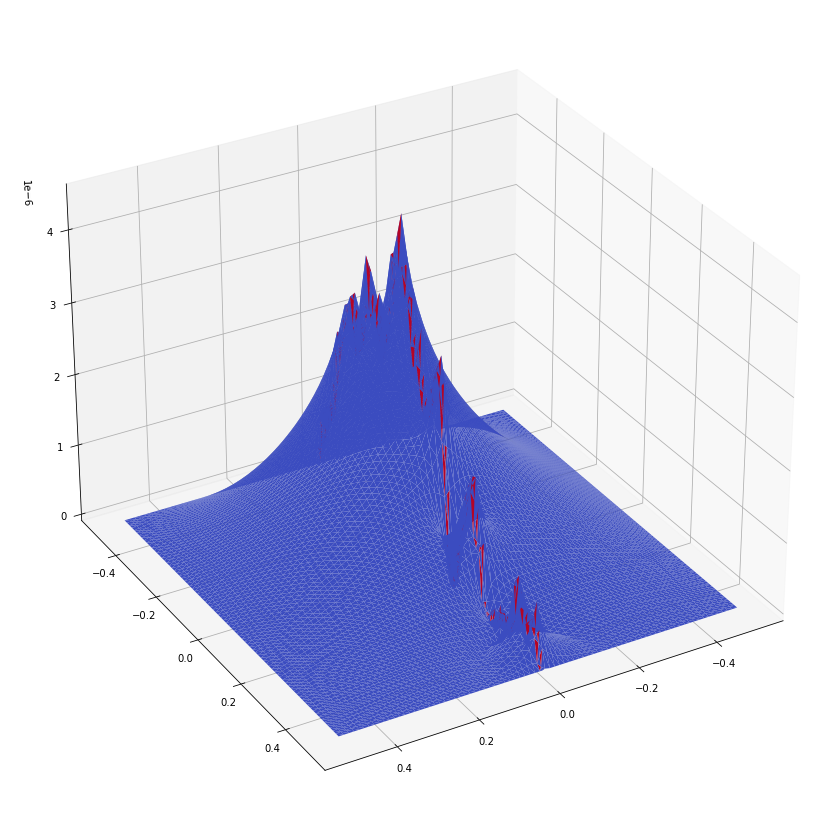

Error:  4.525141258111126e-06


In [9]:
#VISUALIZATION OF ERROR
n = 4
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=60)
print ("Error: ", ddr.calc_L0_error(mesh,u,ref_sol))


4 1.1102230246251565e-16 -0.6 1.0
5 1.1657341758564144e-15 -0.19999999999999996 1.0
8 2.220446049250313e-16 1.0 1.0
11 1.1102230246251565e-15 1.0 1.0
13 2.7755575615628914e-17 0.19999999999999996 1.0
14 2.498001805406602e-16 -0.19999999999999996 1.0
36 1.7732618311811643e-19 0.0 1.0
46 1.2042008493175337e-21 0.0 1.0
36 1.7732618311811643e-19 0.0 1.0


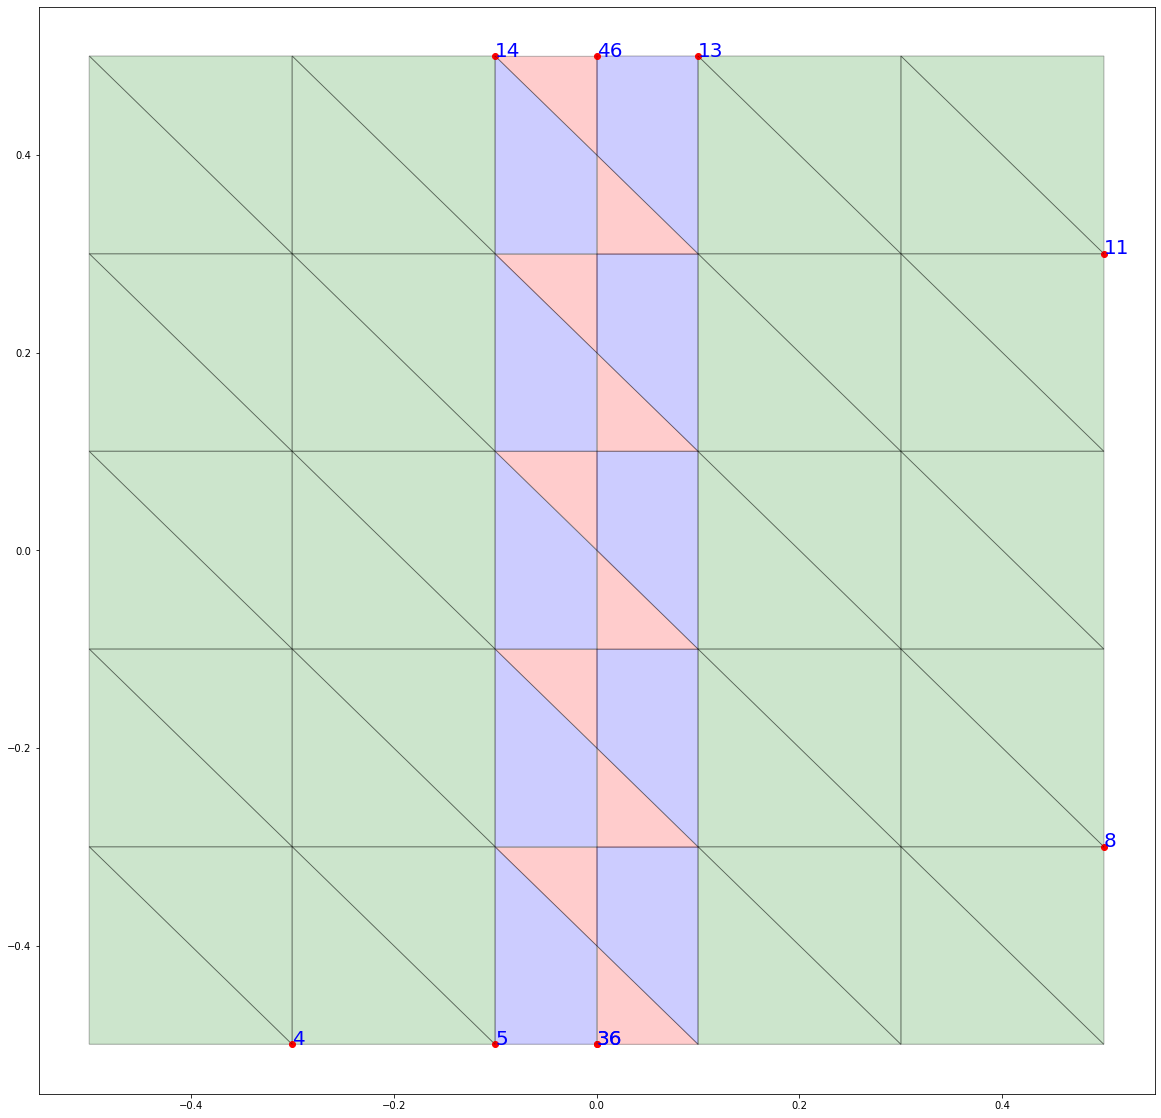

In [66]:
def check(mesh,u, u_ref, b, A):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
                color = 'red'
            else:
                nvert = 4
                color = 'blue'
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
                color = 'green'
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               verts.append(p1[0:2])
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
    # spot problematic points
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            if (abs(u[dof]-u_ref[dof])>0):
                    print (ino, abs(u[ino]-u_ref[ino]), b[dof], A[dof,dof])
                    text_position = mesh.coords[ino,:]
                    text_content_1 = str(b[dof])
                    text_content_2 = str(ino)
                    text_content_3 = str(A[dof,dof])
                    xx = mesh.coords[ino, 0]
                    yy = mesh.coords[ino, 1]
                    #ax.text(xx, yy, text_content_1, fontsize=20, color='red')
                    ax.text(xx, yy, text_content_2, fontsize=20, color='blue')
                    point = ax.scatter(xx,yy,color='red')

b = b_vectors[n]
A = A_matrices[n]
check(mesh, u, u_ref, b, A)

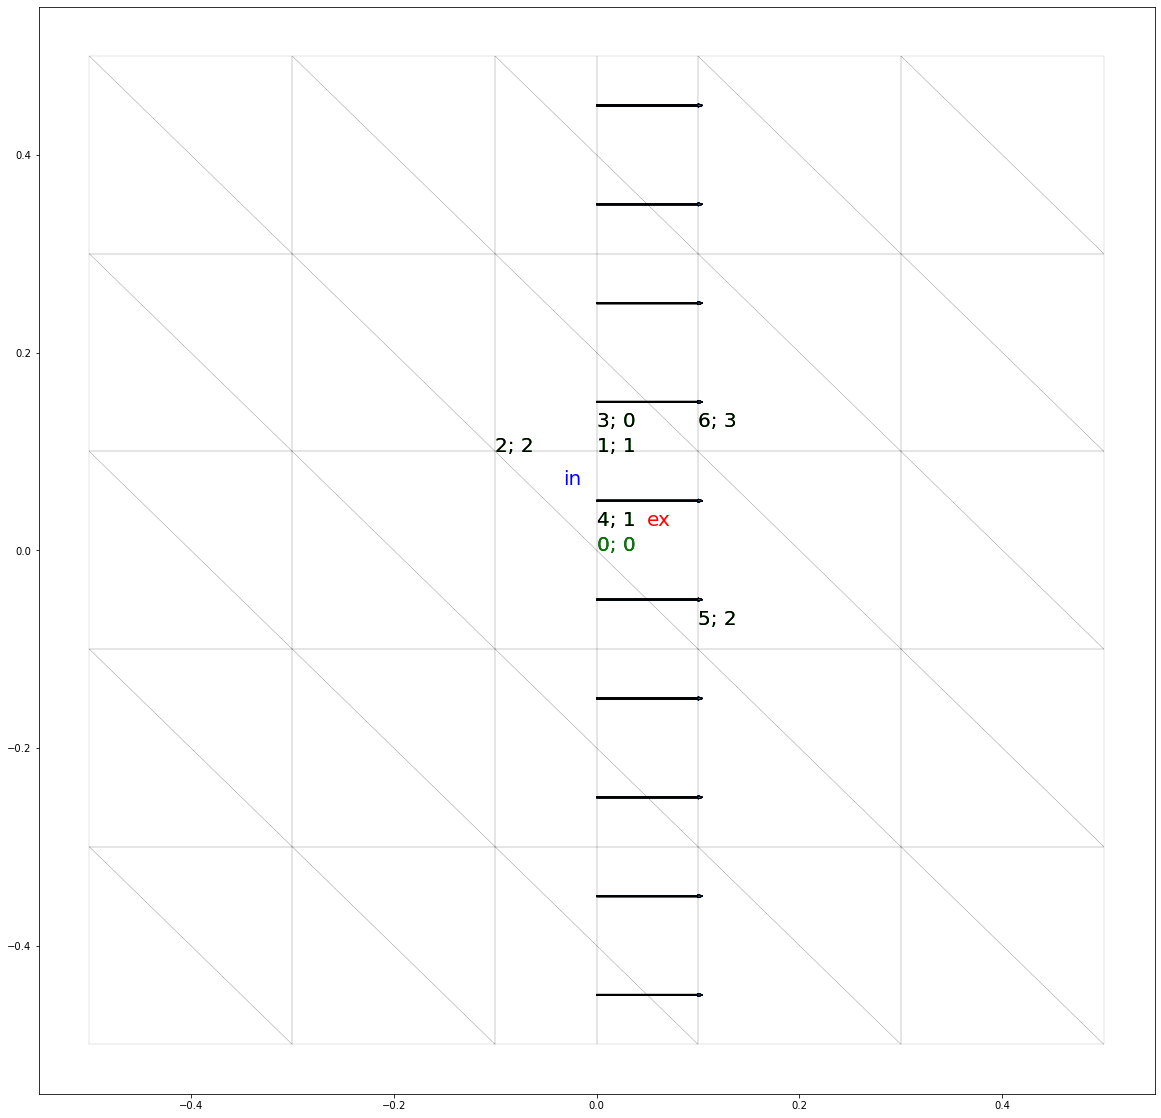

In [82]:
def assemble_M_gamma(mesh,sigma_in,sigma_ex):
    to_check = 5
    fig, ax = plt.subplots(figsize=(20,20))
    # visualize underlying mesh#####################################
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    #################################################################
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    for ied in range(mesh.gamma_edges.shape[0]):
        # table of dofs touched by the edge
        # 7 dofs: 3 from the triangle + 4 from the quad
        edge_dofs = np.zeros((7,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied,0]
        ifa_ex = mesh.gamma_edges[ied,1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        if (ied==to_check):
            # show two faces ###################################
            pos_ifa_in = ddr.barycenter(mesh,ifa_in)
            pos_ifa_ex = ddr.barycenter(mesh,ifa_ex)
            ax.text(pos_ifa_in[0], pos_ifa_in[1], "in", fontsize=20, color='blue')
            ax.text(pos_ifa_ex[0], pos_ifa_ex[1], "ex", fontsize=20, color='red')
            ####################################################
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh,ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
        for idof1 in range(7):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face$
            # Show dofs############################################################
            if (ied==to_check):
                if (dof1<mesh.Npoints):
                    ino = dof1
                else:
                    ino = dof1 - (mesh.Npoints-mesh.Npoints_init)
                text_pos= mesh.coords[ino,0:2]+np.array([0,0.025])*(ifa1==ifa_ex)
                text = str(idof1)+"; "+str(dof1_loc)
                ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='black')
            ########################################################################
            GR1 = ddr.GR(mesh,ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            tangent = mesh.coords[mesh.faces[ifa1,1],0:2]-mesh.coords[mesh.faces[ifa1,0],0:2]
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)
            normal = sign1*np.array([[0,1],[-1,0]])@tangent
            # add it to plot
            midpoint  = 0.5*(mesh.coords[mesh.faces[ifa1,1],0:2]+mesh.coords[mesh.faces[ifa1,0],0:2])
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
            #
            mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc],normal)
            for idof2 in range(7):
                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1]
                R2 = ddr.recpot(mesh,ifa2)
                # Show dofs###########################################################
                if (ied==to_check and idof1==0):
                    if (dof2<mesh.Npoints):
                        ino = dof2
                    else:
                        ino = dof2 - (mesh.Npoints-mesh.Npoints_init)
                    text_pos= mesh.coords[ino,0:2]+np.array([0,0.025])*(ifa2==ifa_ex)
                    text = str(idof2)+"; "+str(dof2_loc)
                    ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='green')
                #######################################################################
                ## Setting node prec as first vertex and node post as second
                ## should be indifferent though
                node_per_face_2 = np.count_nonzero(mesh.faces[ifa2,:] != -1)
                if (node_per_face_2 ==4):
                    v2A = R2[0,dof2_loc]
                    v2B = R2[1,dof2_loc]
                else:
                    v2A = R2[1,dof2_loc]
                    v2B = R2[0,dof2_loc]
                # sign (jump must be ex-in)
                sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                ## integral
                jump_of_rec = 0.5*(v2A+v2B)*sign2
                M_gamma[dof1,dof2] = M_gamma[dof1,dof2] + mean_sigma_grad_normal*jump_of_rec
        
    return M_gamma                                                                                  
mesh = Meshes[0]
M_gamma_test = assemble_M_gamma(mesh, sigma_min ,sigma_plus)

## NEUMANN CONDS VERSION

In [7]:
def mark_bnd_points(mesh): # order to avoid overwriting corners
    # boundary mask, code:
    # 0: internal
    # 1: x=-0.5
    # 2: y=-0.5
    # 3: x= 0.5
    # 4: y= 0.5
    for ino in range(mesh.Npoints):
        if (abs(mesh.coords[ino,1]+0.5)<1e-6):
            mesh.bnd_mask[ino] = 2
        if (abs(mesh.coords[ino,1]-0.5)<1e-6):
            mesh.bnd_mask[ino] = 4
        if (abs(mesh.coords[ino,0]+0.5)<1e-6):
            mesh.bnd_mask[ino]= 1
        if (abs(mesh.coords[ino,0]-0.5)<1e-6):
            mesh.bnd_mask[ino] = 3


def impose_bc(mesh,A,b,ref_sol):
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]%2>0):
            b[dof] = ref_sol(mesh,dof)
            A[dof,:] = 0.0
            A[dof,dof] = 1
    return [A,b]


In [23]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40, 80]
mesh_filenames = ["square_struc_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_struc_L1_N"+str(size)+".vtk" for size in size_list]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = load_square_mesh(mesh_filenames[i]) # adapted for structured mesh
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) 
    # break mesh
    ddr.break_mesh_1D(mesh)
    # mark boundaries
    mark_bnd_points(mesh) # version of the test
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus)
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    A = G+S+eta*N_gamma+np.transpose(M_gamma) # system matrix
    #A = G+S+eta*N_gamma-M_gamma 
    b = eta*b_phi
    [A, b] = impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A, b)
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

[2.35627595 0.960224   2.45544177 1.34651858]


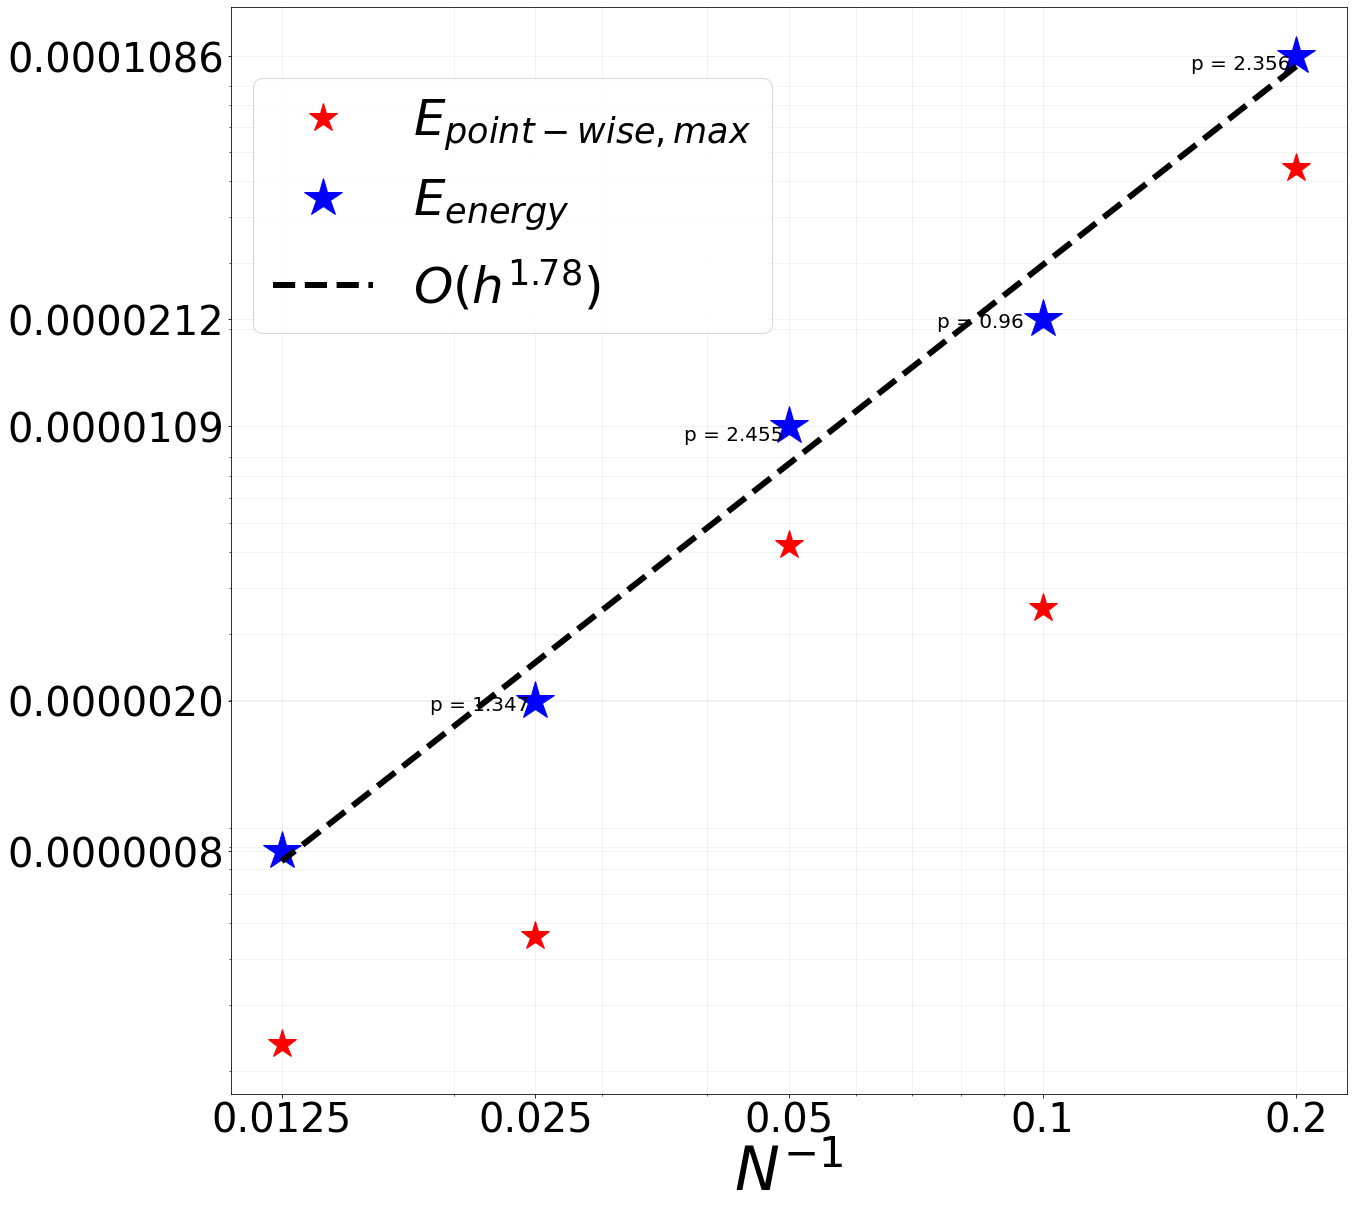

In [24]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = 5

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]


ax.loglog(h,errors_L0, '*', label="$E_{point-wise,max}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
#ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )
#ax.loglog(h,h_sq/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-2})$", color="black", linewidth= line_width )
# estimate and plot order of convergence
orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]
ax.loglog(h,h_p/np.mean(h_p)*np.mean(errors_energy),'--', label="$O(h^{"+str(np.round(p,3))+"})$", color="black", linewidth= line_width )
# print 
for i in range(len(size_list)-1):
    text = "p = "+str(np.round(orders[i],3))
    pos_x = 0.5*(h[i+1]+h[i])
    pos_y = 0.5*(errors_energy[i+1]+errors_energy[i]) - 0.4*(errors_energy[i+1]-errors_energy[i])
    ax.text(pos_x, pos_y, text, fontsize=20, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

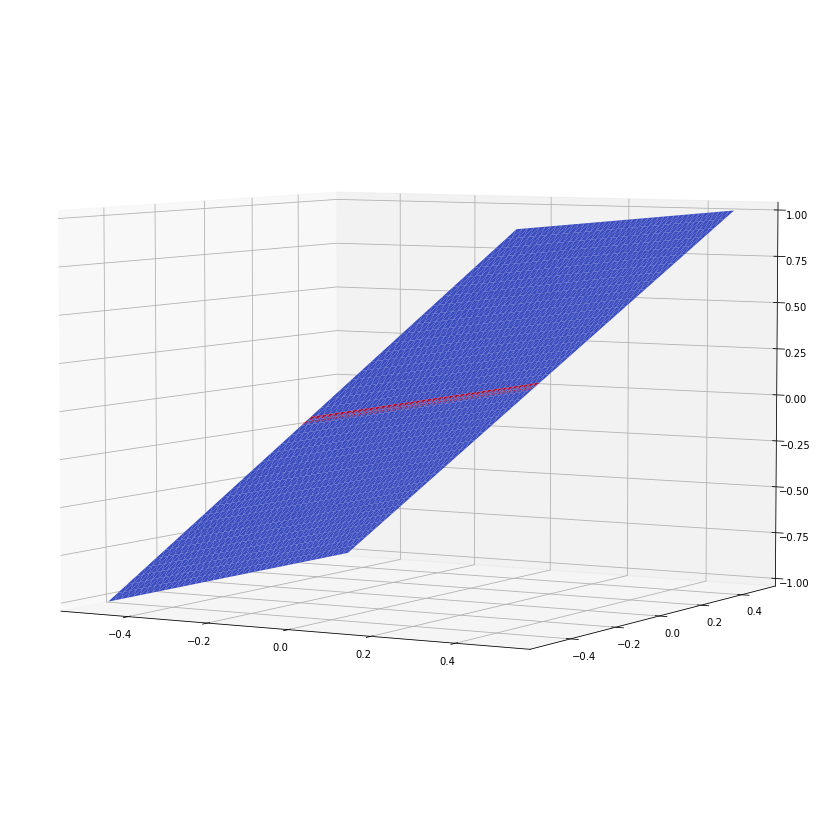

Error:  1.9882193695491265e-06


In [25]:
n = 3
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=5, azimuth=-60)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))

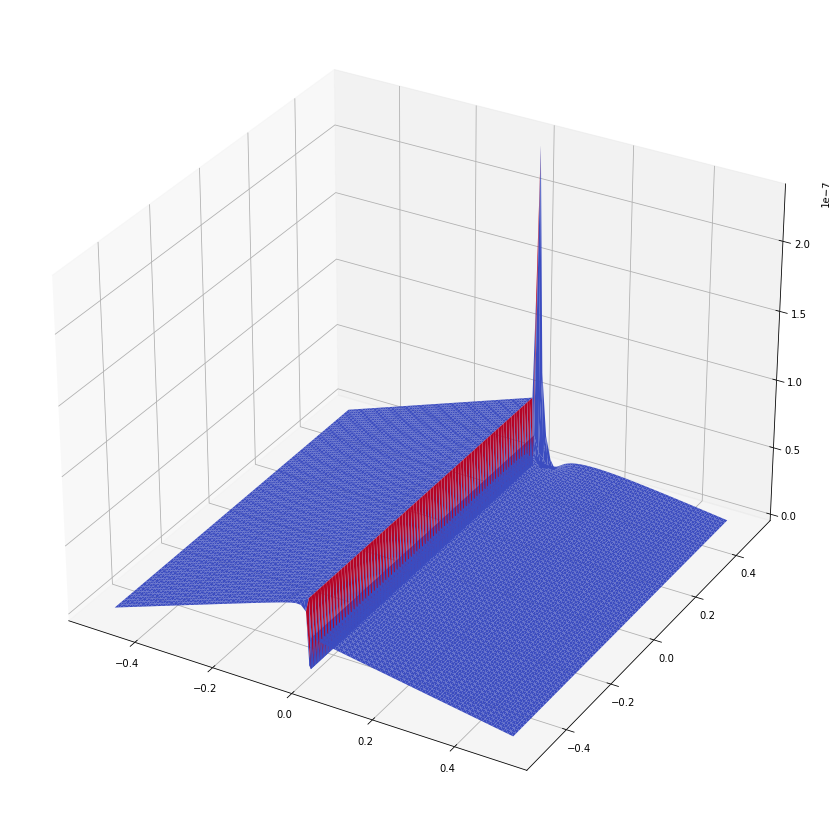

Error:  0.0


In [26]:
#VISUALIZATION OF ERROR
n = 4
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=-60)
print ("Error: ", ddr.calc_L0_error(mesh,u_ref,ref_sol))

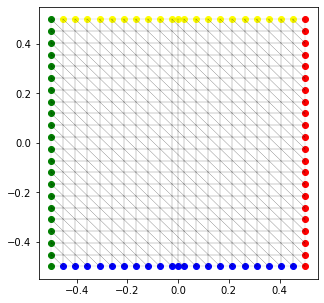

In [20]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    
visualize_bnd_points_with_dof(Meshes[2])